Using Colab cache for faster access to the 'mnist-dataset' dataset.
Data Splits Configuration -> Train: 2100 | Val: 450 | Test: 450

--- Training Started (~10k Params Model) ---


Epoch 1/4 [Training]:   0%|          | 0/2100 [00:00<?, ?it/s]

Epoch 1/4 [Validation]:   0%|          | 0/450 [00:00<?, ?it/s]

✨ Epoch 1 Complete -> Train Loss: 0.819 | Train Acc: 74.43% | Val Loss: 0.451 | Val Acc: 85.56%



Epoch 2/4 [Training]:   0%|          | 0/2100 [00:00<?, ?it/s]

...

Epoch 3/4 [Validation]:   0%|          | 0/450 [00:00<?, ?it/s]

✨ Epoch 3 Complete -> Train Loss: 0.340 | Train Acc: 89.38% | Val Loss: 0.396 | Val Acc: 88.67%



Epoch 4/4 [Training]:   0%|          | 0/2100 [00:00<?, ?it/s]

Epoch 4/4 [Validation]:   0%|          | 0/450 [00:00<?, ?it/s]

✨ Epoch 4 Complete -> Train Loss: 0.293 | Train Acc: 90.81% | Val Loss: 0.392 | Val Acc: 89.33%



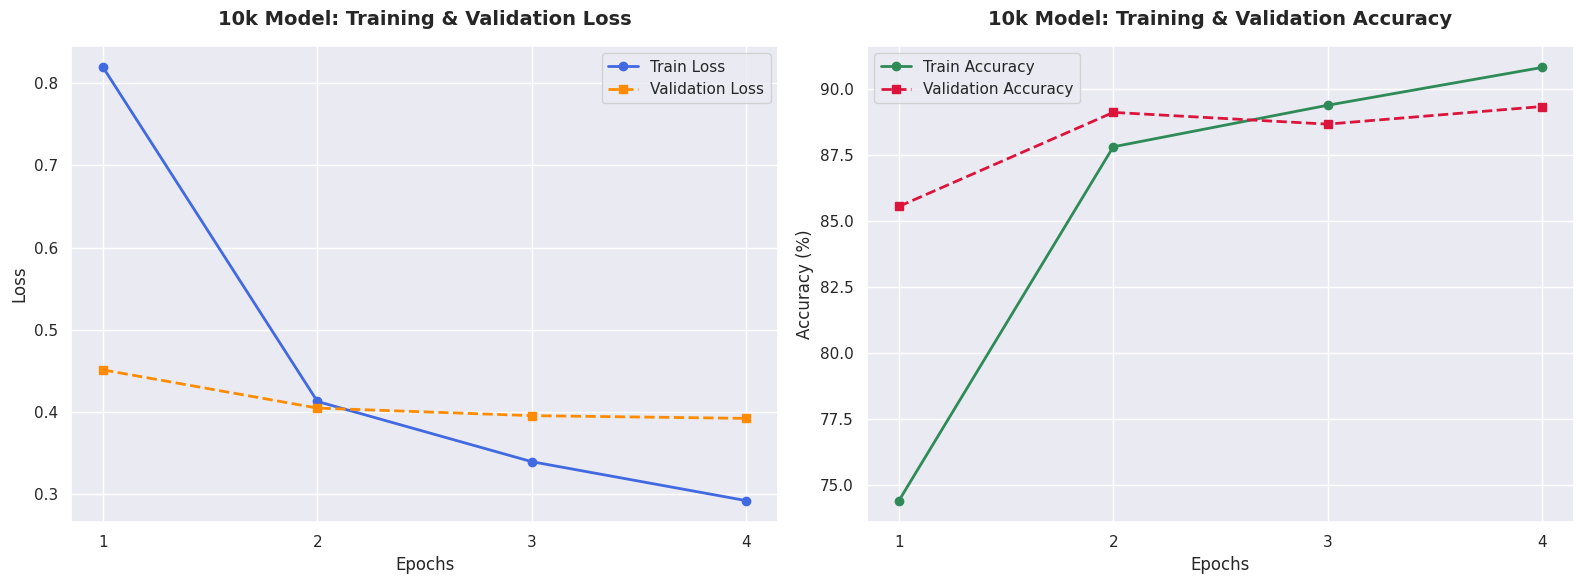


FINAL TEST ACCURACY (10K MODEL): 91.78%


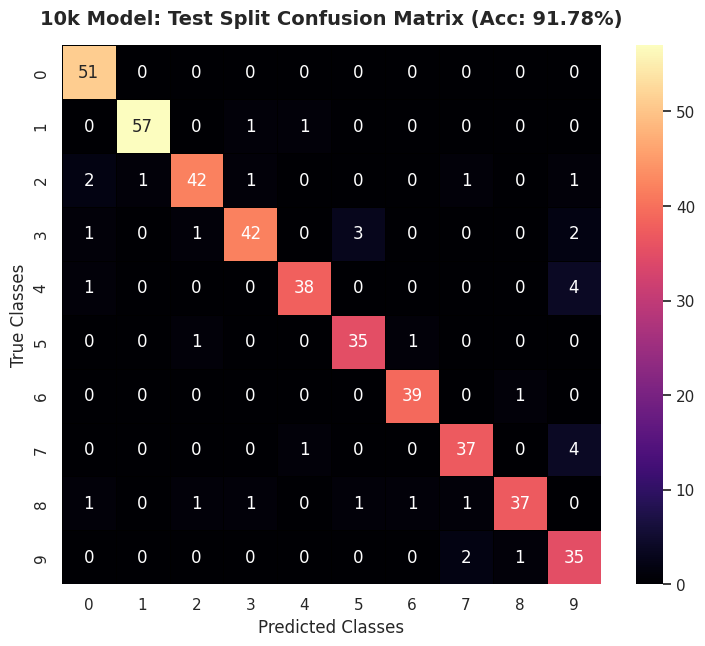

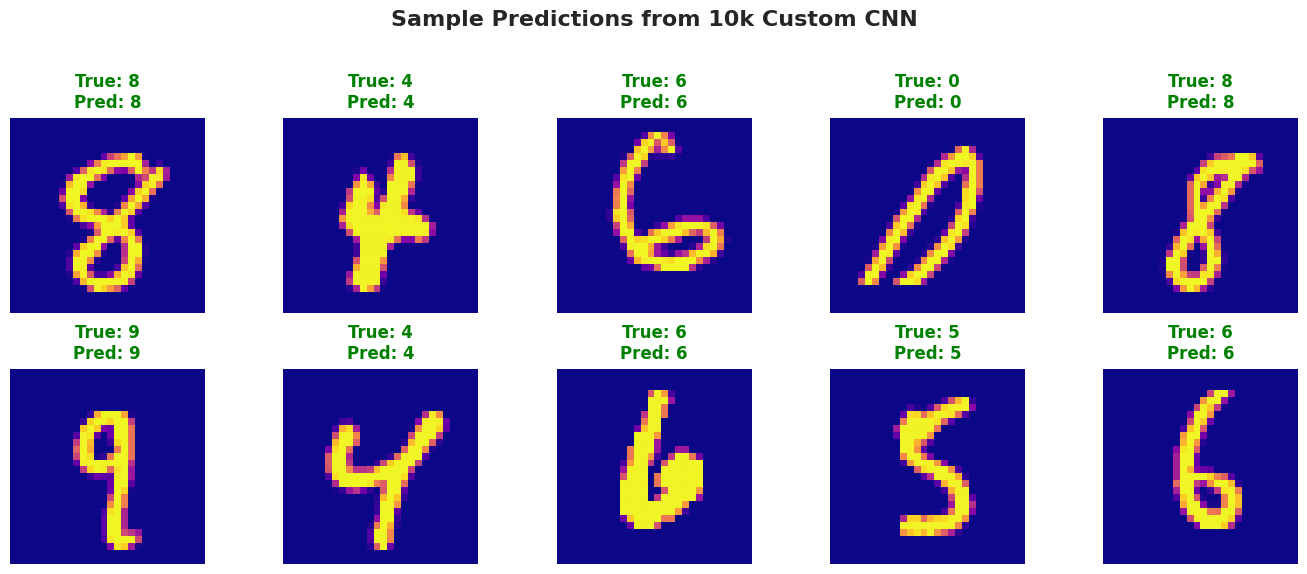

In [1]:
import os
import gzip
import numpy as np
import kagglehub
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
from tqdm.notebook import tqdm

# 1. Download and Load MNIST Dataset
path = kagglehub.dataset_download("hojjatk/mnist-dataset")

def find_file(base_path, target_name):
    for root, dirs, files in os.walk(base_path):
        for file in files:
            if target_name in file:
                return os.path.join(root, file)
    raise FileNotFoundError(f"File containing '{target_name}' not found.")

train_images_path = find_file(path, 'train-images')
train_labels_path = find_file(path, 'train-labels')

def load_mnist_images(filename):
    with open(filename, 'rb') as f:
        data = np.frombuffer(f.read(), np.uint8, offset=16)
    return data.reshape(-1, 28, 28) / 255.0

def load_mnist_labels(filename):
    with open(filename, 'rb') as f:
        return np.frombuffer(f.read(), np.uint8, offset=8)

X_all = load_mnist_images(train_images_path)
y_all = load_mnist_labels(train_labels_path)

# 2. 70/15/15 Data Split (Total 3000 images for clean validation tracking)
total_samples = 3000
indices = np.arange(total_samples)
np.random.seed(42)
np.random.shuffle(indices)

train_end = int(total_samples * 0.70)           # 70% = 2100 images
val_end = train_end + int(total_samples * 0.15)       # 15% = 450 images

X_train, y_train = X_all[indices[:train_end]], y_all[indices[:train_end]]
X_val, y_val = X_all[indices[train_end:val_end]], y_all[indices[train_end:val_end]]
X_test, y_test = X_all[indices[val_end:]], y_all[indices[val_end:]]

print(f"Data Splits Configuration -> Train: {len(X_train)} | Val: {len(X_val)} | Test: {len(X_test)}")

# 3. 10k Parameter Model Architecture (6 Filters instead of 8)
class Conv3x3:
    def __init__(self, num_filters):
        self.num_filters = num_filters
        # 6 filters of 3x3 size
        self.filters = np.random.randn(num_filters, 3, 3) / 9

    def iterate_regions(self, image):
        h, w = image.shape
        for i in range(h - 2):
            for j in range(w - 2):
                yield image[i:(i + 3), j:(j + 3)], i, j

    def forward(self, input):
        self.last_input = input
        h, w = input.shape
        output = np.zeros((h - 2, w - 2, self.num_filters))
        for im_region, i, j in self.iterate_regions(input):
            output[i, j] = np.sum(im_region * self.filters, axis=(1, 2))
        return output

    def backward(self, d_l_d_out, learn_rate):
        d_l_d_filters = np.zeros(self.filters.shape)
        for im_region, i, j in self.iterate_regions(self.last_input):
            for f in range(self.num_filters):
                d_l_d_filters[f] += d_l_d_out[i, j, f] * im_region
        self.filters -= learn_rate * d_l_d_filters
        return None

class MaxPool2:
    def iterate_regions(self, image):
        h, w, _ = image.shape
        for i in range(h // 2):
            for j in range(w // 2):
                yield image[(i * 2):(i * 2 + 2), (j * 2):(j * 2 + 2)], i, j

    def forward(self, input):
        self.last_input = input
        h, w, num_filters = input.shape
        output = np.zeros((h // 2, w // 2, num_filters))
        for im_region, i, j in self.iterate_regions(input):
            output[i, j] = np.amax(im_region, axis=(0, 1))
        return output

    def backward(self, d_l_d_out):
        d_l_d_input = np.zeros(self.last_input.shape)
        for im_region, i, j in self.iterate_regions(self.last_input):
            h, w, f = im_region.shape
            amax = np.amax(im_region, axis=(0, 1))
            for i2 in range(h):
                for j2 in range(w):
                    for f2 in range(f):
                        if im_region[i2, j2, f2] == amax[f2]:
                            d_l_d_input[i * 2 + i2, j * 2 + j2, f2] = d_l_d_out[i, j, f2]
        return d_l_d_input

class Softmax:
    def __init__(self, input_len, nodes):
        # 1014 input nodes to 10 outputs = ~10k params
        self.weights = np.random.randn(input_len, nodes) / input_len
        self.biases = np.zeros(nodes)

    def forward(self, input):
        self.last_input_shape = input.shape
        input = input.flatten()
        self.last_input = input
        totals = np.dot(input, self.weights) + self.biases
        self.last_totals = totals
        exp = np.exp(totals - np.max(totals))
        return exp / np.sum(exp, axis=0)

    def backward(self, d_l_d_out, learn_rate):
        for i, gradient in enumerate(d_l_d_out):
            if gradient == 0:
                continue
            t_exp = np.exp(self.last_totals)
            S = np.sum(t_exp)
            d_out_d_t = -t_exp[i] * t_exp / (S ** 2)
            d_out_d_t[i] = t_exp[i] * (S - t_exp[i]) / (S ** 2)
            d_l_d_t = gradient * d_out_d_t

            d_l_d_w = self.last_input[:, np.newaxis] @ d_l_d_t[np.newaxis, :]
            d_l_d_b = d_l_d_t
            d_l_d_inputs = self.weights @ d_l_d_t

            self.weights -= learn_rate * d_l_d_w
            self.biases -= learn_rate * d_l_d_b
            return d_l_d_inputs.reshape(self.last_input_shape)

# Initialize modules with 6 filters (Total ~10,210 Parameters)
conv = Conv3x3(6)
pool = MaxPool2()
softmax = Softmax(13 * 13 * 6, 10)

def forward_pass(image, label):
    out = conv.forward((image - 0.5))
    out = pool.forward(out)
    out = softmax.forward(out)
    loss = -np.log(out[label] + 1e-10)
    acc = 1 if np.argmax(out) == label else 0
    return out, loss, acc

def train_step(im, label, lr=0.005):
    out, loss, acc = forward_pass(im, label)
    gradient = np.zeros(10)
    gradient[label] = -1 / (out[label] + 1e-10)
    gradient = softmax.backward(gradient, lr)
    gradient = pool.backward(gradient)
    gradient = conv.backward(gradient, lr)
    return loss, acc

# 4. Training Loop with Live Progress Bar
epochs = 4
history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}

print("\n--- Training Started (~10k Params Model) ---")
for epoch in range(epochs):
    train_loss, train_correct = 0, 0

    # tqdm যুক্ত ট্রেইনিং লুপ (এটি লাইভ প্রোগ্রেস বার দেখাবে)
    train_loop = tqdm(zip(X_train, y_train), total=len(X_train), desc=f"Epoch {epoch+1}/{epochs} [Training]")
    for im, label in train_loop:
        l, acc = train_step(im, label)
        train_loss += l
        train_correct += acc
        # বারের ডানপাশে লাইভ এক্যুরেসি ও লস আপডেট করার জন্য
        train_loop.set_postfix(loss=f"{l:.3f}", acc=f"{acc*100}%")

    val_loss, val_correct = 0, 0
    # ভ্যালিডেশনের জন্যও প্রোগ্রেস বার (খুব দ্রুত চলে যাবে)
    val_loop = tqdm(zip(X_val, y_val), total=len(X_val), desc=f"Epoch {epoch+1}/{epochs} [Validation]", leave=False)
    for im, label in val_loop:
        _, l, acc = forward_pass(im, label)
        val_loss += l
        val_correct += acc

    # মেট্রিকেস হিসাব করা
    epoch_train_loss = train_loss / len(X_train)
    epoch_train_acc = (train_correct / len(X_train)) * 100
    epoch_val_loss = val_loss / len(X_val)
    epoch_val_acc = (val_correct / len(X_val)) * 100

    history['train_loss'].append(epoch_train_loss)
    history['train_acc'].append(epoch_train_acc)
    history['val_loss'].append(epoch_val_loss)
    history['val_acc'].append(epoch_val_acc)

    # ফাইনাল ইপোক সামারি প্রিন্ট
    print(f"✨ Epoch {epoch+1} Complete -> Train Loss: {epoch_train_loss:.3f} | Train Acc: {epoch_train_acc:.2f}% | Val Loss: {epoch_val_loss:.3f} | Val Acc: {epoch_val_acc:.2f}%\n")

# 5. GENERATING VISUALIZATIONS
sns.set_theme(style="darkgrid")
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Loss Curve
ax1.plot(range(1, epochs + 1), history['train_loss'], 'o-', label='Train Loss', color='royalblue', linewidth=2)
ax1.plot(range(1, epochs + 1), history['val_loss'], 's--', label='Validation Loss', color='darkorange', linewidth=2)
ax1.set_title('10k Model: Training & Validation Loss', fontsize=14, weight='bold', pad=15)
ax1.set_xlabel('Epochs', fontsize=12)
ax1.set_ylabel('Loss', fontsize=12)
ax1.set_xticks(range(1, epochs + 1))
ax1.legend(fontsize=11)

# Plot 2: Accuracy Curve
ax2.plot(range(1, epochs + 1), history['train_acc'], 'o-', label='Train Accuracy', color='seagreen', linewidth=2)
ax2.plot(range(1, epochs + 1), history['val_acc'], 's--', label='Validation Accuracy', color='crimson', linewidth=2)
ax2.set_title('10k Model: Training & Validation Accuracy', fontsize=14, weight='bold', pad=15)
ax2.set_xlabel('Epochs', fontsize=12)
ax2.set_ylabel('Accuracy (%)', fontsize=12)
ax2.set_xticks(range(1, epochs + 1))
ax2.legend(fontsize=11)

plt.tight_layout()
plt.show()

# 6. Evaluation on Unseen Test Split
test_preds = []
for im in X_test:
    out, _, _ = forward_pass(im, 0)
    test_preds.append(np.argmax(out))

test_acc = np.mean(np.array(test_preds) == y_test) * 100
print(f"\n===========================================\nFINAL TEST ACCURACY (10K MODEL): {test_acc:.2f}%\n===========================================")

# Plot 3: Confusion Matrix (Magma Skin)
cm = confusion_matrix(y_test, test_preds)
plt.figure(figsize=(9, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='magma', linewidths=0.5, linecolor='black', square=True)
plt.title(f"10k Model: Test Split Confusion Matrix (Acc: {test_acc:.2f}%)", fontsize=14, weight='bold', pad=15)
plt.xlabel("Predicted Classes", fontsize=12)
plt.ylabel("True Classes", fontsize=12)
plt.show()

# Plot 4: Prediction Grid (Plasma Skin)
plt.figure(figsize=(14, 6))
plt.suptitle("Sample Predictions from 10k Custom CNN", fontsize=16, weight='bold', y=0.98)

for idx in range(10):
    plt.subplot(2, 5, idx + 1)
    img = X_test[idx]
    actual = int(y_test[idx])
    pred = int(test_preds[idx])
    title_color = 'green' if actual == pred else 'red'

    plt.imshow(img, cmap='plasma')
    plt.title(f"True: {actual}\nPred: {pred}", color=title_color, fontsize=12, weight='bold', pad=8)
    plt.axis('off')

plt.tight_layout(pad=2.0)
plt.show()
